In [1]:
pip install pandas numpy openpyxl scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
from scipy import stats

In [7]:
file_path = r"D:\全球健康风险因素\2023全球疾病负担研究.xlsx"
df = pd.read_excel(file_path, engine="openpyxl", header=0)

In [8]:
print("✅ 数据读取成功！")
print("原始数据行数×列数：", df.shape)
print("\n原始列名：")
print(df.columns.tolist())
print("\n前5行数据预览：")
print(df.head())

✅ 数据读取成功！
原始数据行数×列数： (19584, 11)

原始列名：
['population_group', 'measure', 'location', 'sex', 'age', 'cause', 'metric', 'year', 'val', 'upper', 'lower']

前5行数据预览：
  population_group measure                  location   sex       age  \
0   All Population  Deaths                    Poland  Both  All ages   
1   All Population  Deaths                  Suriname  Both  All ages   
2   All Population  Deaths                Cabo Verde  Both  All ages   
3   All Population  Deaths  Central African Republic  Both  All ages   
4   All Population  Deaths                      Chad  Both  All ages   

                                     cause   metric  year       val     upper  \
0                                Neoplasms  Percent  2000  0.265549  0.272711   
1                   Unintentional injuries  Percent  2000  0.033619  0.038937   
2  Respiratory infections and tuberculosis  Percent  2000  0.107760  0.135448   
3                 Nutritional deficiencies  Percent  2000  0.008327  0.011137   
4 

In [9]:
df = df.dropna(how="all").dropna(axis=1, how='all').drop_duplicates()    # 删全空行、全空列、重复行
print("基础清洗后数据形状：", df.shape)

基础清洗后数据形状： (19584, 11)


In [10]:
rename_dict = {
    "location": "country",
    "year": "year",
    "val": "mortality",
    "cause": "disease"
}
df = df.rename(columns=rename_dict)
print("重命名后列名：", df.columns.tolist())

重命名后列名： ['population_group', 'measure', 'country', 'sex', 'age', 'disease', 'metric', 'year', 'mortality', 'upper', 'lower']


In [11]:
numeric_cols = ["mortality", "upper", "lower"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=["country", "year", "mortality"])
print("处理后形状：", df.shape)

处理后形状： (19584, 11)


In [12]:
from scipy import stats
for col in ["mortality", "upper", "lower"]:
    z_score = np.abs(stats.zscore(df[col], nan_policy='omit'))
    df = df[z_score < 3]           # Z分数法剔除极端异常值（Z>3）

df = df.sort_values(["country", "year"]).reset_index(drop=True)   # 按国家-年份排序，构造标准面板数据

print("异常值处理后形状：", df.shape)
print("前5行预览：")
print(df.head())

异常值处理后形状： (18655, 11)
前5行预览：
  population_group measure      country   sex       age  \
0   All Population  Deaths  Afghanistan  Both  All ages   
1   All Population  Deaths  Afghanistan  Both  All ages   
2   All Population  Deaths  Afghanistan  Both  All ages   
3   All Population  Deaths  Afghanistan  Both  All ages   
4   All Population  Deaths  Afghanistan  Both  All ages   

                                   disease   metric  year  mortality  \
0                                Neoplasms  Percent  2000   0.029880   
1                   Unintentional injuries  Percent  2000   0.034658   
2  Respiratory infections and tuberculosis  Percent  2000   0.128196   
3                 Nutritional deficiencies  Percent  2000   0.021343   
4                                Neoplasms  Percent  2001   0.030873   

      upper     lower  
0  0.037865  0.022942  
1  0.049468  0.024586  
2  0.170010  0.091441  
3  0.028393  0.015709  
4  0.039082  0.023369  


In [13]:
df.to_excel("GBD2023_清洗完成.xlsx", index=False)
df.to_csv("GBD2023_清洗完成.csv", index=False, encoding="utf-8-sig")
print("✅ 清洗完成，文件已导出")

✅ 清洗完成，文件已导出


In [14]:
import os
print(os.getcwd())

D:\mypy


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [16]:
print("==== 描述统计 ====")
print(df.describe())

==== 描述统计 ====
               year     mortality         upper         lower
count  18655.000000  18655.000000  18655.000000  18655.000000
mean    2011.468561      0.059119      0.067788      0.051264
std        6.926428      0.061839      0.069126      0.055855
min     2000.000000      0.000052      0.000060      0.000044
25%     2005.000000      0.014761      0.017863      0.011474
50%     2011.000000      0.035695      0.041849      0.029854
75%     2017.000000      0.086066      0.099088      0.072596
max     2023.000000      0.271473      0.312353      0.246958


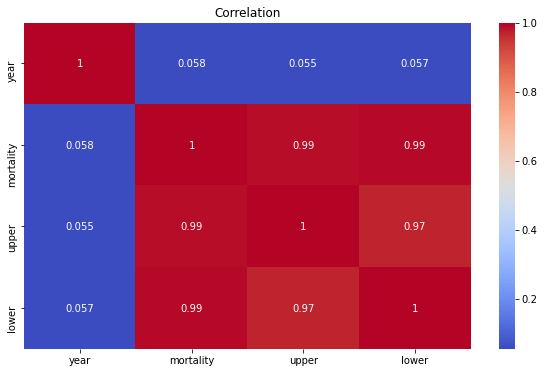

In [17]:
plt.figure(figsize=(10,6))
corr = df[["year","mortality","upper","lower"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation")
plt.show()           #相关系数热力图（ortality（死亡率）与upper/lower（置信区间上下限）强正相关（0.99），说明数据区间合理，无异常。
                      #year（年份）与死亡率几乎无相关（0.058），2000-2023 年整体死亡率无明显线性趋势

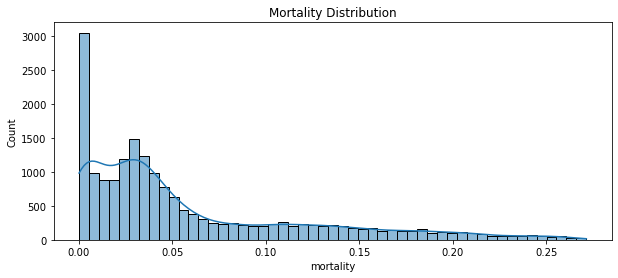

In [18]:
plt.figure(figsize=(10,4))
sns.histplot(df["mortality"], kde=True)
plt.title("Mortality Distribution")
plt.show()     #死亡率分布

ModuleNotFoundError: No module named 'xgboost'

In [20]:
!pip install xgboost shap scikit-learn

  Attempting uninstall: packaging
    Found existing installation: packaging 20.9
    Uninstalling packaging-20.9:
      Successfully uninstalled packaging-20.9


In [21]:
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [22]:
le = LabelEncoder()
df['country_enc'] = le.fit_transform(df['country'])
df['disease_enc'] = le.fit_transform(df['disease'])   # 编码分类变量

In [23]:
X = df[['year', 'country_enc', 'disease_enc']]
y = df['mortality']            # 特征与标签

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = xgb.XGBRegressor(random_state=42)
model.fit(X_train, y_train)        # 训练XGBoost模型

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [26]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)     # SHAP分析

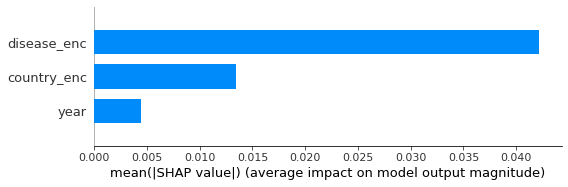

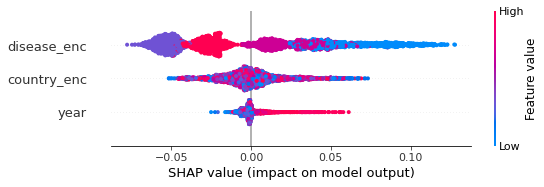

In [27]:
shap.summary_plot(shap_values, X_test, plot_type="bar")  # 特征重要性图
shap.summary_plot(shap_values, X_test)  # 蜂群图（看影响方向）